<a href="https://colab.research.google.com/github/Mohitsahu-07/ML-based-Optical-Character-Recognition/blob/main/Optical_Character_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#IMPORTS
import os
import cv2
from PIL import Image
import skimage.io as io
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from skimage.filters import threshold_otsu
from skimage.morphology import erosion, dilation
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from skimage.feature import hog
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from PIL import Image
from keras.utils import to_categorical
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Image Preprocessing

Our first task is to split the combined images into 5 parts containing single letters. We apply image preprocessing after the split as the function parameters which we use can be different for different parts of the same image depending on the noise concentration or the contrast or the pixel intensities of that part.

In [ ]:
import os

images_folder = "/content/drive/MyDrive/samples1000"

files = os.listdir(images_folder)

print("Total files:", len(files))
print("First 20 files:")
for f in files[:20]:
    print(repr(f))

Total files: 1000
First 20 files:
'aaqzm.png'
'abhtl.png'
'abmau.png'
'abyix.png'
'acgtb.png'
'acjln.png'
'acqwi.png'
'acuyo.png'
'addbr.png'
'adjll.png'
'adtdq.png'
'adyuw.png'
'aepvv.png'
'afeok.png'
'affdm.png'
'afrcz.png'
'ahdzs.png'
'ahmpf.png'
'ahwwz.png'
'aijbf.png'


The following cell needs to be executed only once to create the samples_split folder which will contain the 5000 individual character images after the split.

On observing the image name contains the letters in the image in order. So, after splitting we are saving the part names in the format -

[ letter ][ image_name ].png

In [ ]:
from PIL import Image

def split(image):
    # Get image dimensions
    width, height = image.size

    # Divide image into 5 equal parts
    part_width = width // 5
    part_height = height

    image_parts = []

    for i in range(5):

        left = i * part_width
        upper = 0
        right = left + part_width
        lower = part_height

        # Crop image
        part = image.crop((left, upper, right, lower))

        image_parts.append(part)

    return image_parts

print("split() function ready!")

split() function ready!


In [ ]:
import os
from PIL import Image

images_folder = "/content/drive/MyDrive/samples1000"
output_folder = "/content/drive/MyDrive/samples_split"

count = 0

for image_name in os.listdir(images_folder):

    if not image_name.endswith(".png"):
        continue

    image_path = os.path.join(images_folder, image_name)

    image = Image.open(image_path)

    # Split image into 5 parts
    image_parts = split(image)

    # Remove .png
    base_name = os.path.splitext(image_name)[0]

    for i, part in enumerate(image_parts):

        # Get corresponding letter from filename
        label = base_name[i]

        # Unique filename
        new_name = f"{label}_{base_name}_{i}.png"

        output_path = os.path.join(output_folder, new_name)

        part.save(output_path)

        count += 1

print("Total images created:", count)

Total images created: 5000


In [ ]:
print("Total split images:", len(os.listdir(output_folder)))

Total split images: 5000


Here we start defining the various image preprocessing functions that we have tried and tested to remove the noise and make the character more clear to improve our dataset.

We are passing image object as the parameter in our functions and have to convert it to a numpy array to apply the preprocessing technique and then convert it back into an image object before returning it.


In [ ]:
def grayscale(image):
    return image.convert('L')

MORPHOLOGICAL OPERATIONS


In [ ]:
def dilate(image):
    image_array = np.array(image)
    kernel = np.ones((3, 3), np.uint8)
    dilated_image = cv2.dilate(image_array, kernel, iterations=2)
    return Image.fromarray(dilated_image)

In [ ]:
def denoise(image):
    image_array = np.array(image)
    denoised_array = cv2.fastNlMeansDenoising(
        image_array, None, 10, 10, 7
    )
    return Image.fromarray(denoised_array)

Various filters we tried out to remove the noise.

In [ ]:
def median_filter(image):
    image_array = np.array(image)
    filtered_image = cv2.medianBlur(image_array, 9)
    return Image.fromarray(filtered_image)

In [ ]:
def histogram_equalization(image):
    image_array = np.array(image)
    equalized_image = cv2.equalizeHist(image_array)
    return Image.fromarray(equalized_image)

In [ ]:
def resize(image):
    image_array = np.array(image)
    resized_array = cv2.resize(
        image_array,
        (64, 128),
        interpolation=cv2.INTER_AREA
    )
    return Image.fromarray(resized_array)

In [ ]:
def preprocess(img):
    img = resize(img)
    img = grayscale(img)
    img = histogram_equalization(img)
    img = dilate(img)
    img = denoise(img)
    img = median_filter(img)
    return img

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder_path = "/content/drive/MyDrive/samples_split"

files = os.listdir(folder_path)

image_path = os.path.join(folder_path, files[0])

image = Image.open(image_path)

preprocessed_image = preprocess(image)

print("Image:", files[0])
print("Original size:", image.size)
print("Preprocessed size:", preprocessed_image.size)

Image: a_aaqzm_0.png
Original size: (20, 100)
Preprocessed size: (64, 128)


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

folder_path = "/content/drive/MyDrive/samples_split"

files = os.listdir(folder_path)

image_path = os.path.join(folder_path, files[0])

image = Image.open(image_path)

preprocessed_image = preprocess(image)

print("Image:", files[0])
print("Original size:", image.size)
print("Preprocessed size:", preprocessed_image.size)

Image: a_aaqzm_0.png
Original size: (20, 100)
Preprocessed size: (64, 128)


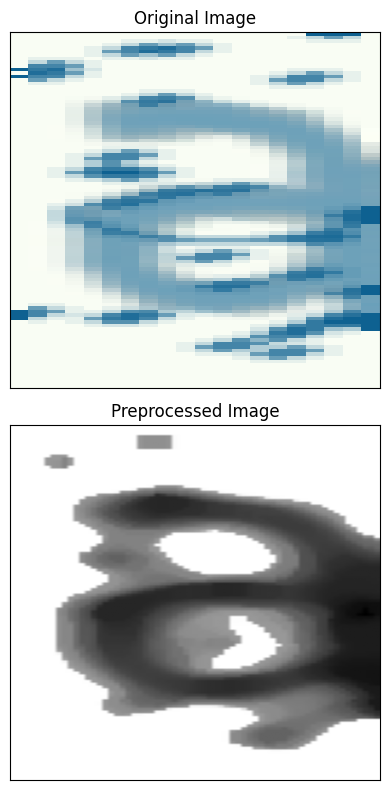

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 8))

ax1.imshow(image, 'gray', aspect='auto')
ax1.set_title('Original Image')
ax1.set_xticks([])
ax1.set_yticks([])

ax2.imshow(preprocessed_image, 'gray', aspect='auto')
ax2.set_title('Preprocessed Image')
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
plt.show()

# MACHINE LEARNING

Now, we begin the Machine Learning part.

We have created functions to extract features, load our images and then prepare a features dataset for all the images.

In [ ]:
def extract_features(image):
    # Extract HOG features
    features = hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(1, 1))
    return features

In [ ]:
def load_images(folder_path):
    images = []
    labels = []
    number = [0]*26
    for part_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, part_name)
        image = Image.open(image_path)
        part_name = os.path.basename(image_path)
        number[ord(part_name[0])-ord('a')]+=1
        image = preprocess(image)
        images.append(image)

        labels.append(part_name[0])  # Part name format is [label][part_name].png
    return images, labels, number

In [ ]:
def prepare_data(images, labels):
    features = []

    for image in images:
        features.append(extract_features(image))

    X = np.array(features,dtype=object)
    y = np.array(labels)

    return X, y

In [ ]:
# Load and prepare the data
folder_path = "/content/drive/MyDrive/samples_split"

images, labels, number = load_images(folder_path)
X, y = prepare_data(images, labels)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=80)

In [ ]:
print(number)

[202, 193, 197, 189, 194, 196, 179, 171, 175, 204, 184, 205, 210, 199, 190, 189, 185, 172, 210, 180, 190, 178, 186, 205, 204, 213]


<Axes: ylabel='count'>

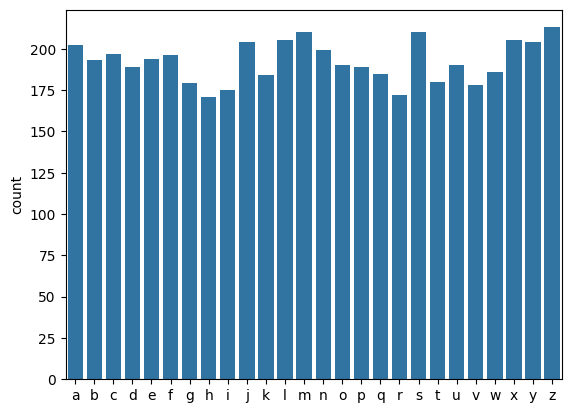

In [ ]:
class_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
sns.countplot(x=labels, order=class_labels)

Now we implement basic forms of the three specified classifiers - Logistic Regression, Support Vector Machine, Random Forest.

In [ ]:

# Create and train the Logistic Regression classifier
lrclf = LogisticRegression()
lrclf.fit(X_train, y_train)
y_pred = lrclf.predict(X_test)

# Evaluate the Logistic Regression classifier
lraccuracy = lrclf.score(X_test, y_test)
print("LR Accuracy:", 100*lraccuracy)
precision = precision_score(y_test, y_pred, average='micro')
print("LR Precision:", precision)
recall = recall_score(y_test, y_pred, average='micro')
print("LR Recall:", recall)
f1 = f1_score(y_test, y_pred, average='micro')
print("LR F1 score:", f1)


# Create and train the SVM classifier
svmclf = SVC(kernel='linear')
svmclf.fit(X_train, y_train)
y_pred = svmclf.predict(X_test)
# Evaluate the SVM classifier
svmaccuracy = svmclf.score(X_test, y_test)
print("SVM Accuracy:", 100*svmaccuracy)
precision = precision_score(y_test, y_pred, average='micro')
print("SVM Precision:", precision)
recall = recall_score(y_test, y_pred, average='micro')
print("SVM Recall:", recall)
f1 = f1_score(y_test, y_pred, average='micro')
print("SVM F1 score:", f1)

# Create and train the Random Forest classifier
rfclf = RandomForestClassifier(n_estimators=100)
rfclf.fit(X_train, y_train)
y_pred = rfclf.predict(X_test)
# Evaluate the Random Forest classifier
rfaccuracy = rfclf.score(X_test, y_test)
print("RF Accuracy:", 100*rfaccuracy)
precision = precision_score(y_test, y_pred, average='micro')
print("RF Precision:", precision)
recall = recall_score(y_test, y_pred, average='micro')
print("RF Recall:", recall)
f1 = f1_score(y_test, y_pred, average='micro')
print("RF F1 score:", f1)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 77.10000000000001
LR Precision: 0.771
LR Recall: 0.771
LR F1 score: 0.771
SVM Accuracy: 76.9
SVM Precision: 0.769
SVM Recall: 0.769
SVM F1 score: 0.769
RF Accuracy: 76.9
RF Precision: 0.769
RF Recall: 0.769
RF F1 score: 0.769


As we find that SVM is the best classifier among the three. We now implement GridSearchCV to find the best hyperparameter combination to maximise accuracy.

In [ ]:
# Create an SVM classifier
svm_classifier = svm.SVC()

# Define the hyperparameters to tune and their possible values
param_grid = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'coef0': [0.0, 0.5, 1.0]
}

# Perform grid search cross-validation
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Train the SVM with the best hyperparameters
best_svm = svm.SVC(**best_params)
best_svm.fit(X_train, y_train)

accuracy = best_svm.score(X_test, y_test)
print(accuracy)

0.808


In [ ]:
svmclf = SVC(kernel='poly', C=10, degree=2, coef0=0.0)
svmclf.fit(X_train, y_train)
svmaccuracy = svmclf.score(X_test, y_test)
print("svmAccuracy:", 100*svmaccuracy)

svmAccuracy: 80.5


In [ ]:
y_pred = svmclf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           a       0.87      0.89      0.88        45
           b       0.72      0.74      0.73        38
           c       0.86      0.91      0.89        34
           d       0.82      0.84      0.83        32
           e       0.85      0.88      0.87        33
           f       0.40      0.57      0.47        30
           g       0.86      0.89      0.88        36
           h       0.74      0.74      0.74        34
           i       0.80      0.75      0.78        44
           j       0.82      0.95      0.88        43
           k       0.84      0.78      0.81        27
           l       0.70      0.84      0.77        37
           m       0.71      0.73      0.72        41
           n       0.79      0.84      0.81        31
           o       0.97      0.85      0.91        41
           p       0.94      0.89      0.91        35
           q       0.90      0.97      0.93        29
           r       0.95    

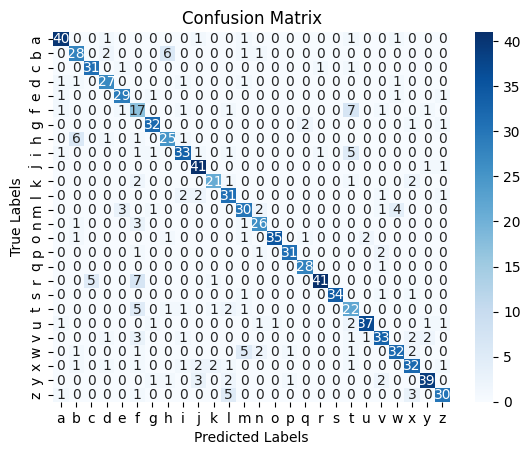

a: 0.89
b: 0.74
c: 0.91
d: 0.84
e: 0.88
f: 0.57
g: 0.89
h: 0.74
i: 0.75
j: 0.95
k: 0.78
l: 0.84
m: 0.73
n: 0.84
o: 0.85
p: 0.89
q: 0.97
r: 0.76
s: 0.92
t: 0.67
u: 0.82
v: 0.75
w: 0.71
x: 0.74
y: 0.80
z: 0.75


In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Define class labels
class_labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

# Create a heatmap using seaborn
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')

# Display the plot
plt.show()

# Print accuracies for each label
accuracies = np.diag(cm) / cm.sum(axis=1)
for i, accuracy in enumerate(accuracies):
    print(f"{class_labels[i]}: {accuracy:.2f}")

Support Vector Machine (SVM) classifier yields the best accuracy on the validation set. Accuracy is the best metric to compare the algorithms as our data is almost balanced on the classes (alphabets). Other metrics such as precision, recall and F1 score are used for different data sets which may be imbalanced.

I ran a GridSearchCV on the model by making a standard parameter grid. We get the best ones among that from there and we tried to tweak them manually after that by changing values at intervals and found that it is the best possible combination.

C determines the penalty for misclassifications made by the SVM during training. A smaller value of C allows for a larger margin, potentially resulting in a simpler decision boundary but with the risk of misclassifying some training examples. On the other hand, a larger value of C puts a higher penalty on misclassifications, leading to a smaller margin and potentially a more complex decision boundary.

In the model increasing the value of C after 9-10 didnt have much of an effect on our accurracy as it becomes a high enough penalty on the misclassifications. Low values of C drastically reduced the accuracy.

The degree parameter controls the flexibility or complexity of the decision boundary. It determines the degree of the polynomial used in the kernel function. A higher degree allows the SVM to capture more complex relationships between the data points, potentially leading to a more flexible decision boundary that can fit the training data more closely. However, using a very high degree can also increase the risk of overfitting, where the model may not generalize well to unseen data.

When using a linear kernel, the SVM learns a linear decision boundary represented by a hyperplane. The coef_ attribute returns the coefficients of this hyperplane. These coefficients indicate the importance or weight assigned to each feature in the decision-making process.

h is at times getting confused and read b. Similarly x is predicted as either f or I. t is at times predicted as c, f and l. v is incorrectly predicted as f. d is incorrectly predicted as a.


# Another approach : CNN

In [ ]:

# Another alternate algortithm: CNN

# Loading images
def load_images(folder_path):
    images = []
    labels = []

    for filename in os.listdir(folder_path):
        if filename.endswith('.png'):
            image_path = os.path.join(folder_path, filename)
            label = ord(filename[0]) - ord('a')  # Convert alphabet label to number

            image = Image.open(image_path)
            image = preprocess(image)
            images.append(image)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

folder_path = "/content/drive/MyDrive/samples_split"

images = []
labels = []

# Load images
for filename in os.listdir(folder_path):

    if not filename.lower().endswith(".png"):
        continue

    image_path = os.path.join(folder_path, filename)

    # First character = label
    label = ord(filename[0].lower()) - ord('a')

    image = Image.open(image_path)

    # Your preprocessing function
    image = preprocess(image)

    # PIL -> NumPy
    image = np.array(image)

    images.append(image)
    labels.append(label)

# Convert to NumPy
X = np.array(images, dtype=np.float32)
y = np.array(labels)

print("Before channel:", X.shape)

# Add channel dimension
X = X[..., np.newaxis]

print("After channel:", X.shape)

# Normalize
X = X / 255.0

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=742,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==============================
# CNN
# ==============================

model = Sequential([
    Input(shape=(128, 64, 1)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(64, activation="relu"),

    Dense(26, activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ==============================
# TRAIN
# ==============================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


# ==============================
# EVALUATE
# ==============================

loss, accuracy = model.evaluate(X_test, y_test)

print("CNN Accuracy:", accuracy * 100, "%")

Before channel: (5000, 128, 64)
After channel: (5000, 128, 64, 1)
X_train: (4000, 128, 64, 1)
X_test : (1000, 128, 64, 1)
y_train: (4000,)
y_test : (1000,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 62, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 26880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     1,720,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,890 (6.64 MB)

 Trainable params: 1,740,890 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 50s 389ms/step - accuracy: 0.1140 - loss: 3.1237 - val_accuracy: 0.2760 - val_loss: 2.5831
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 366ms/step - accuracy: 0.4815 - loss: 1.8498 - val_accuracy: 0.5310 - val_loss: 1.5940
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 366ms/step - accuracy: 0.6910 - loss: 1.0700 - val_accuracy: 0.6350 - val_loss: 1.2470
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 364ms/step - accuracy: 0.7968 - loss: 0.6808 - val_accuracy: 0.6560 - val_loss: 1.1950
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 357ms/step - accuracy: 0.8695 - loss: 0.4216 - val_accuracy: 0.6840 - val_loss: 1.1451
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 366ms/step - accuracy: 0.9380 - loss: 0.2275 - val_accuracy: 0.6970 - val_loss: 1.1633
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 370ms/step - accuracy: 0.9735 - loss: 0.1157 - val_accuracy: 0.7120 - val_loss: 1.2720
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 375ms/step - accuracy: 0.9902 - loss: 0

In [ ]:
from sklearn.feature_extraction import image
from skimage.feature import hog
import numpy as np
import os
from PIL import Image

folder_path = "/content/drive/MyDrive/samples_split"

images = []
labels = []

for filename in os.listdir(folder_path):

    if not filename.endswith(".png"):
        continue

    path = os.path.join(folder_path, filename)

    img = Image.open(path)
    img = preprocess(img)

    # HOG features
    features = hog(
        np.array(img),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(1, 1)
    )

    images.append(features)
    labels.append(filename[0])

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 1152)
y shape: (5000,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=80,
    stratify=y
)

svm_model = SVC(kernel="linear")

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy * 100, "%")
print()
print(classification_report(y_test, y_pred))

SVM Accuracy: 74.8 %

              precision    recall  f1-score   support

           a       0.82      0.70      0.76        40
           b       0.71      0.74      0.72        39
           c       0.83      0.90      0.86        39
           d       0.78      0.74      0.76        38
           e       0.77      0.85      0.80        39
           f       0.61      0.77      0.68        39
           g       0.67      0.89      0.76        36
           h       0.62      0.68      0.65        34
           i       0.61      0.63      0.62        35
           j       0.85      0.83      0.84        41
           k       0.82      0.76      0.79        37
           l       0.54      0.66      0.59        41
           m       0.66      0.69      0.67        42
           n       0.79      0.78      0.78        40
           o       0.83      0.79      0.81        38
           p       1.00      0.89      0.94        38
           q       0.92      0.89      0.90        37
     

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm_model = SVC()

param_grid = {
    'C': [0.1, 1, 10],
    'degree': [2, 3, 4],
    'coef0': [0.0, 0.5, 1.0]
}

grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 10, 'coef0': 0.0, 'degree': 2}
Best CV Score:
0.7895000000000001


In [ ]:
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Best SVM Test Accuracy:", accuracy * 100, "%")

Best SVM Test Accuracy: 78.60000000000001 %


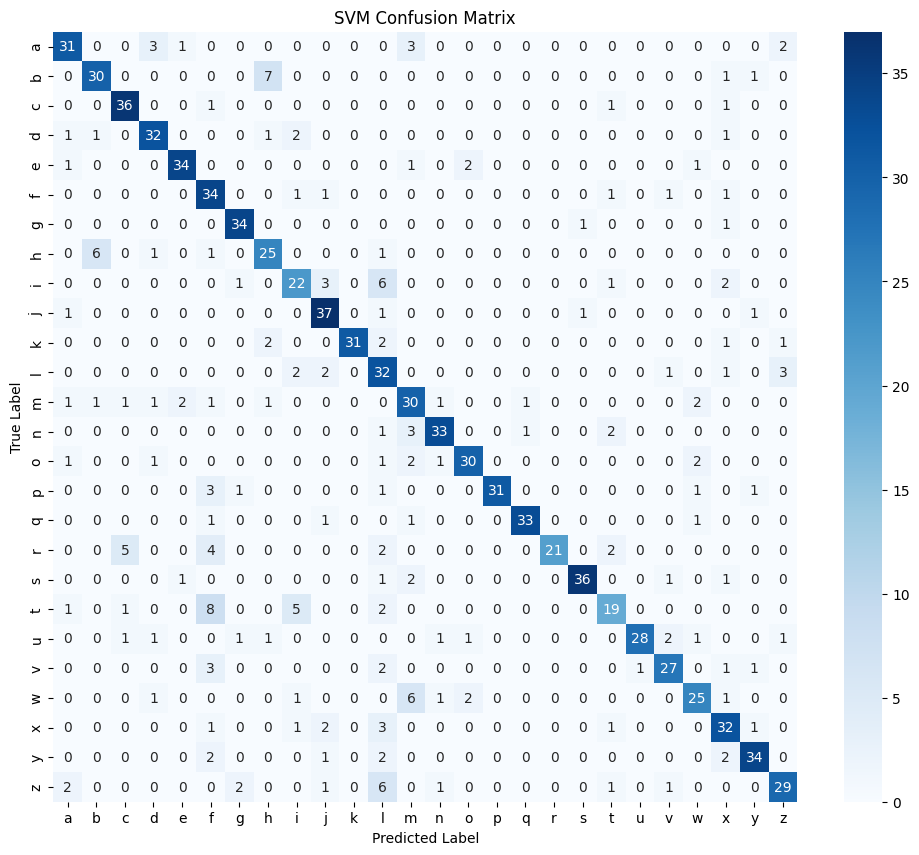

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = best_svm.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

class_labels = [
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i',
    'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r',
    's', 't', 'u', 'v', 'w', 'x', 'y', 'z'
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_labels
))

              precision    recall  f1-score   support

           a       0.79      0.78      0.78        40
           b       0.79      0.77      0.78        39
           c       0.82      0.92      0.87        39
           d       0.80      0.84      0.82        38
           e       0.89      0.87      0.88        39
           f       0.58      0.87      0.69        39
           g       0.87      0.94      0.91        36
           h       0.68      0.74      0.70        34
           i       0.65      0.63      0.64        35
           j       0.77      0.90      0.83        41
           k       1.00      0.84      0.91        37
           l       0.51      0.78      0.62        41
           m       0.62      0.71      0.67        42
           n       0.87      0.82      0.85        40
           o       0.86      0.79      0.82        38
           p       1.00      0.82      0.90        38
           q       0.94      0.89      0.92        37
           r       1.00    

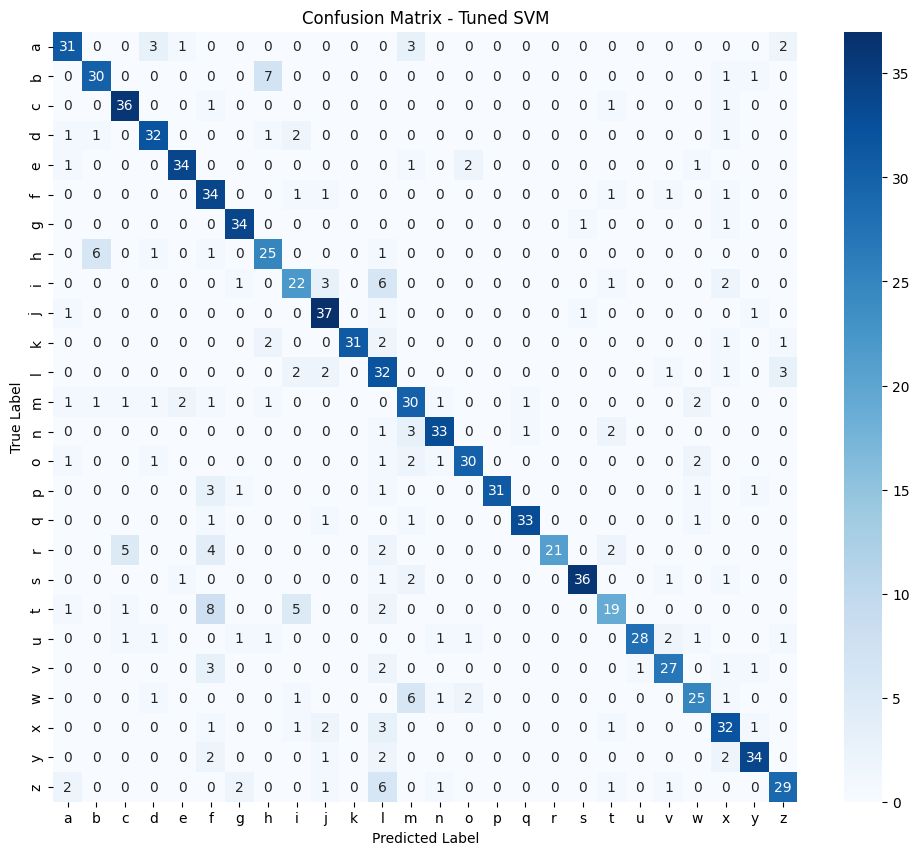

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

class_labels = list("abcdefghijklmnopqrstuvwxyz")

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned SVM")

plt.show()

In [ ]:
accuracies = np.diag(cm) / cm.sum(axis=1)

for label, acc in zip(class_labels, accuracies):
    print(f"{label}: {acc:.2%}")

a: 77.50%
b: 76.92%
c: 92.31%
d: 84.21%
e: 87.18%
f: 87.18%
g: 94.44%
h: 73.53%
i: 62.86%
j: 90.24%
k: 83.78%
l: 78.05%
m: 71.43%
n: 82.50%
o: 78.95%
p: 81.58%
q: 89.19%
r: 61.76%
s: 85.71%
t: 52.78%
u: 73.68%
v: 77.14%
w: 67.57%
x: 78.05%
y: 82.93%
z: 67.44%
